# Atelier : Analyse Discriminante de Fisher et SVM

**SYS800 - Reconnaissance de formes**

Dans cet atelier, nous allons explorer :
- **L'Analyse Discriminante de Fisher (FDA)** : réduction de dimensionnalité supervisée
- **Les Machines à Vecteurs de Support (SVM)** : séparateurs à marge maximale

Ces deux méthodes adoptent une approche **géométrique** de la classification.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Ellipse
import seaborn as sns

from sklearn.datasets import load_iris, load_wine, make_blobs, make_moons
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC

# Configuration
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
np.random.seed(42)

---
# Partie 1 : Analyse Discriminante de Fisher
---

## 1.1 Motivation : Projection discriminante

L'idée de Fisher est de projeter les données sur une direction $\mathbf{w}$ qui **maximise la séparation** entre les classes.

Projection d'un point : $y_n = \mathbf{w}^\top \mathbf{x}_n$

**Problème :** Maximiser la distance entre les moyennes projetées ne suffit pas !

In [25]:
# Génération de données 2D pour illustration
np.random.seed(42)

# Deux classes gaussiennes avec covariances orientées
n_samples = 100

# Classe 1 : covariance orientée
mean1 = np.array([0, 0])
cov1 = np.array([[3, 2], [2, 2]])
X1 = np.random.multivariate_normal(mean1, cov1, n_samples)

# Classe 2 : même covariance, décalée
mean2 = np.array([3, 3])
cov2 = cov1  # Même covariance pour simplifier
X2 = np.random.multivariate_normal(mean2, cov2, n_samples)

X_demo = np.vstack([X1, X2])
t_demo = np.array([0]*n_samples + [1]*n_samples)

print(f"Données générées : {X_demo.shape[0]} points, 2 classes")

Données générées : 200 points, 2 classes


In [26]:
def project_and_plot(X, t, w, ax, title):
    """
    Projette les données sur w et affiche les histogrammes.
    """
    colors = ['#e41a1c', '#377eb8']
    
    # Normaliser w
    w = w / np.linalg.norm(w)
    
    # Projections
    projections = X @ w
    
    # Sous-plot 1 : données 2D avec direction de projection
    ax[0].scatter(X[t==0, 0], X[t==0, 1], c=colors[0], alpha=0.6, label='Classe 1')
    ax[0].scatter(X[t==1, 0], X[t==1, 1], c=colors[1], alpha=0.6, label='Classe 2')
    
    # Ligne de projection
    origin = X.mean(axis=0)
    ax[0].annotate('', xy=origin + 3*w, xytext=origin - 3*w,
                   arrowprops=dict(arrowstyle='->', lw=2, color='black'))
    ax[0].set_xlabel('$x_1$')
    ax[0].set_ylabel('$x_2$')
    ax[0].set_title(f'{title} - Direction w')
    ax[0].legend()
    ax[0].set_aspect('equal')
    
    # Sous-plot 2 : histogrammes des projections
    ax[1].hist(projections[t==0], bins=20, alpha=0.7, color=colors[0], label='Classe 1')
    ax[1].hist(projections[t==1], bins=20, alpha=0.7, color=colors[1], label='Classe 2')
    ax[1].set_xlabel('Projection $y = \mathbf{w}^\\top \mathbf{x}$')
    ax[1].set_ylabel('Fréquence')
    ax[1].set_title(f'{title} - Distribution projetée')
    ax[1].legend()
    
    # Calcul du critère de Fisher
    m1 = projections[t==0].mean()
    m2 = projections[t==1].mean()
    s1 = projections[t==0].var()
    s2 = projections[t==1].var()
    J = (m1 - m2)**2 / (s1 + s2)
    
    return J

<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
C:\Users\cleme\AppData\Local\Temp\ipykernel_14384\2145797579.py:30: SyntaxWarning: invalid escape sequence '\m'
  ax[1].set_xlabel('Projection $y = \mathbf{w}^\\top \mathbf{x}$')


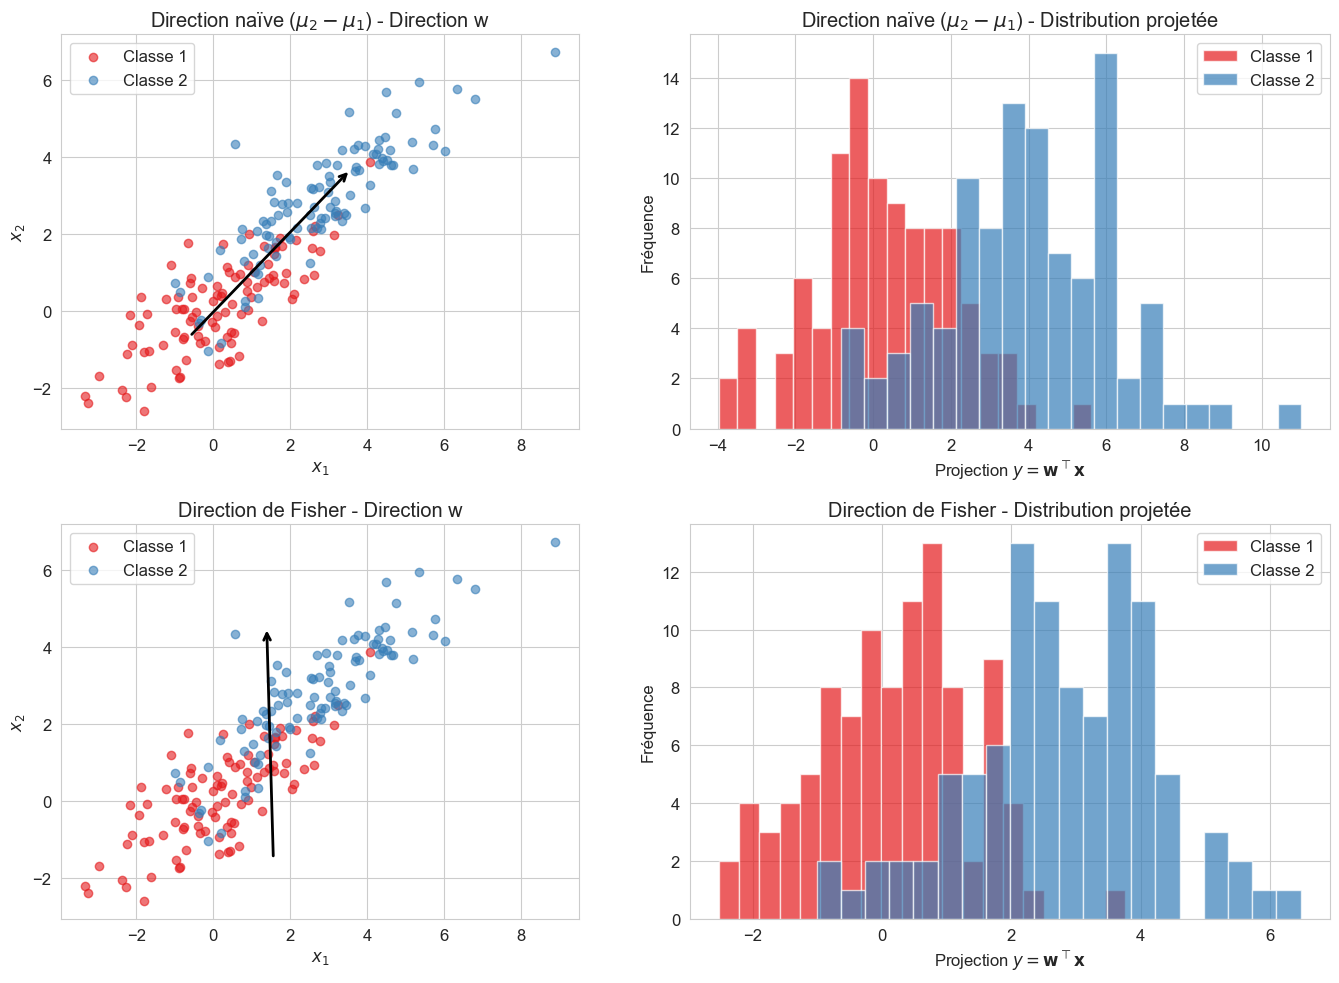

Critère de Fisher J(w) :
  Direction naïve : J = 1.7222
  Direction Fisher : J = 1.9591


In [27]:
# Comparaison de deux directions de projection
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Direction 1 : différence des moyennes (naïve)
mu1 = X_demo[t_demo==0].mean(axis=0)
mu2 = X_demo[t_demo==1].mean(axis=0)
w_naive = mu2 - mu1

J_naive = project_and_plot(X_demo, t_demo, w_naive, axes[0], r'Direction naïve ($\mu_2 - \mu_1$)')

# Direction 2 : Fisher (optimale)
# Calculons-la manuellement
S1 = np.cov(X_demo[t_demo==0].T) * (n_samples - 1)
S2 = np.cov(X_demo[t_demo==1].T) * (n_samples - 1)
S_W = S1 + S2
w_fisher = np.linalg.inv(S_W) @ (mu2 - mu1)

J_fisher = project_and_plot(X_demo, t_demo, w_fisher, axes[1], 'Direction de Fisher')

plt.tight_layout()
plt.show()

print(f"Critère de Fisher J(w) :")
print(f"  Direction naïve : J = {J_naive:.4f}")
print(f"  Direction Fisher : J = {J_fisher:.4f}")

### Question 1
Pourquoi la direction de Fisher donne-t-elle une meilleure séparation ? Observez les histogrammes.

## 1.2 Le critère de Fisher

Le **critère de Fisher** maximise le ratio variance inter-classe / variance intra-classe :

$$J(\mathbf{w}) = \frac{(m_1 - m_2)^2}{s_1^2 + s_2^2} = \frac{\mathbf{w}^\top \mathbf{S}_B \mathbf{w}}{\mathbf{w}^\top \mathbf{S}_W \mathbf{w}}$$

où :
- $\mathbf{S}_W$ : matrice de dispersion **intra-classe** (within)
- $\mathbf{S}_B$ : matrice de dispersion **inter-classe** (between)

In [28]:
def compute_scatter_matrices(X, t):
    """
    Calcule les matrices de dispersion S_W et S_B.
    
    Retourne : S_W, S_B, moyennes par classe, moyenne globale
    """
    classes = np.unique(t)
    K = len(classes)
    N, D = X.shape
    
    # Moyenne globale
    mu = X.mean(axis=0)
    
    # Moyennes par classe
    means = np.array([X[t == k].mean(axis=0) for k in classes])
    
    # Matrice intra-classe S_W
    S_W = np.zeros((D, D))
    for k in classes:
        X_k = X[t == k]
        S_W += (X_k - means[k]).T @ (X_k - means[k])
    
    # Matrice inter-classe S_B
    S_B = np.zeros((D, D))
    for k in classes:
        N_k = np.sum(t == k)
        diff = (means[k] - mu).reshape(-1, 1)
        S_B += N_k * (diff @ diff.T)
    
    return S_W, S_B, means, mu

# Calcul pour nos données de démonstration
S_W, S_B, means, mu_global = compute_scatter_matrices(X_demo, t_demo)

print("Matrice de dispersion intra-classe S_W :")
print(S_W)
print(f"\nMatrice de dispersion inter-classe S_B :")
print(S_B)
print(f"\nRang de S_B : {np.linalg.matrix_rank(S_B)} (attendu : K-1 = 1)")

Matrice de dispersion intra-classe S_W :
[[532.42672409 359.7812144 ]
 [359.7812144  368.00379553]]

Matrice de dispersion inter-classe S_B :
[[334.29226146 347.06250534]
 [347.06250534 360.32058323]]

Rang de S_B : 1 (attendu : K-1 = 1)


## 1.3 Solution de Fisher

La direction optimale est donnée par :

$$\mathbf{w}^* \propto \mathbf{S}_W^{-1}(\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)$$

Pour le cas multi-classe, on résout le problème aux valeurs propres généralisé :
$$\mathbf{S}_W^{-1} \mathbf{S}_B \mathbf{w} = \lambda \mathbf{w}$$

In [29]:
def fisher_discriminant(X, t, n_components=None):
    """
    Implémentation manuelle de l'Analyse Discriminante de Fisher.
    
    Paramètres:
    -----------
    X : array (N, D) - données
    t : array (N,) - étiquettes
    n_components : int - nombre de composantes (max K-1)
    
    Retourne:
    ---------
    W : array (D, n_components) - matrice de projection
    eigenvalues : valeurs propres associées
    """
    classes = np.unique(t)
    K = len(classes)
    D = X.shape[1]
    
    if n_components is None:
        n_components = K - 1
    
    # Matrices de dispersion
    S_W, S_B, _, _ = compute_scatter_matrices(X, t)
    
    # Régularisation si S_W est singulière
    S_W_reg = S_W + 1e-6 * np.eye(D)
    
    # Problème aux valeurs propres : S_W^{-1} S_B w = λ w
    eigenvalues, eigenvectors = np.linalg.eig(np.linalg.inv(S_W_reg) @ S_B)
    
    # Trier par valeurs propres décroissantes
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx].real
    eigenvectors = eigenvectors[:, idx].real
    
    # Sélectionner les n_components premiers
    W = eigenvectors[:, :n_components]
    eigenvalues = eigenvalues[:n_components]
    
    return W, eigenvalues

# Test sur les données 2D
W_manual, eigenvalues = fisher_discriminant(X_demo, t_demo, n_components=1)
print(f"Direction de Fisher (vecteur propre) :")
print(f"  w = {W_manual.flatten()}")
print(f"  Valeur propre : λ = {eigenvalues[0]:.4f}")

Direction de Fisher (vecteur propre) :
  w = [ 0.02859866 -0.99959097]
  Valeur propre : λ = 0.9795


## 1.4 Comparaison PCA vs Fisher

In [30]:
# Chargement du dataset Iris pour une comparaison plus riche
iris = load_iris()
X_iris = iris.data
t_iris = iris.target

# PCA : maximise la variance totale
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris)

# Fisher (LDA) : maximise la séparation des classes
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_iris, t_iris)

# Notre implémentation manuelle
W_our, _ = fisher_discriminant(X_iris, t_iris, n_components=2)
X_our = X_iris @ W_our

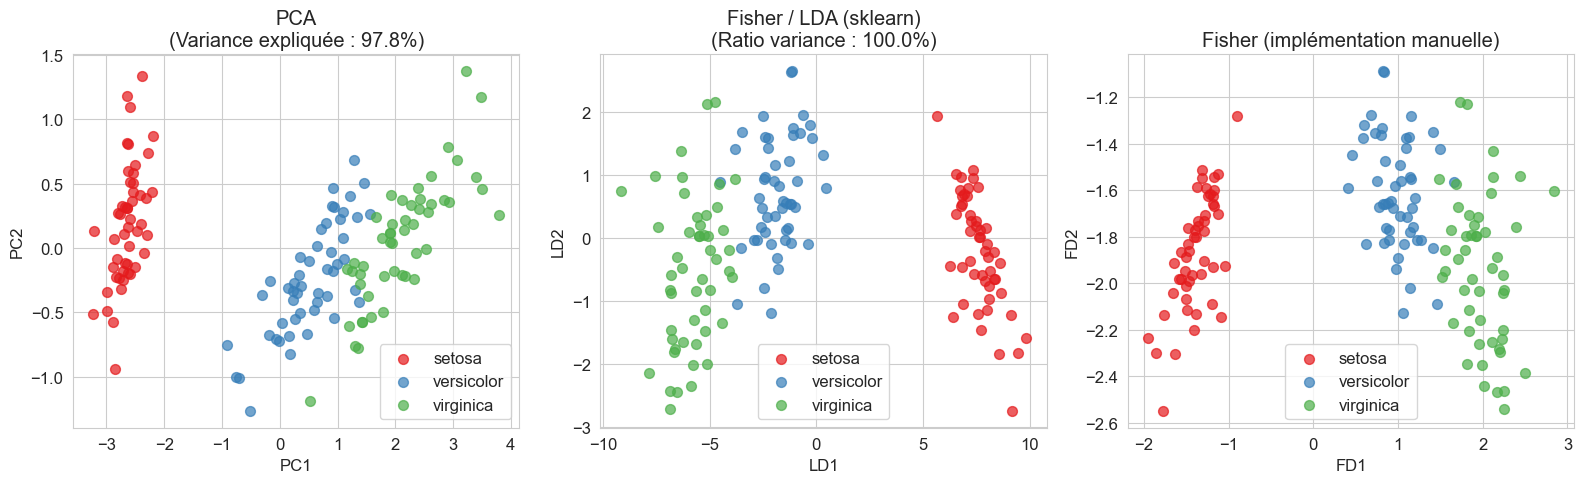

In [31]:
# Visualisation comparative
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#e41a1c', '#377eb8', '#4daf4a']

# PCA
ax = axes[0]
for k in range(3):
    mask = t_iris == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[k], 
               label=iris.target_names[k], alpha=0.7, s=50)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'PCA\n(Variance expliquée : {pca.explained_variance_ratio_.sum():.1%})')
ax.legend()

# Fisher (sklearn)
ax = axes[1]
for k in range(3):
    mask = t_iris == k
    ax.scatter(X_lda[mask, 0], X_lda[mask, 1], c=colors[k], 
               label=iris.target_names[k], alpha=0.7, s=50)
ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_title(f'Fisher / LDA (sklearn)\n(Ratio variance : {lda.explained_variance_ratio_.sum():.1%})')
ax.legend()

# Fisher (implémentation manuelle)
ax = axes[2]
for k in range(3):
    mask = t_iris == k
    ax.scatter(X_our[mask, 0], X_our[mask, 1], c=colors[k], 
               label=iris.target_names[k], alpha=0.7, s=50)
ax.set_xlabel('FD1')
ax.set_ylabel('FD2')
ax.set_title('Fisher (implémentation manuelle)')
ax.legend()

plt.tight_layout()
plt.show()

### Question 2
Comparez les projections PCA et Fisher. Laquelle sépare mieux les classes ? Pourquoi ?

In [32]:
# Performance de classification après réduction de dimension
from sklearn.neighbors import KNeighborsClassifier

# k-NN dans l'espace original
knn_original = KNeighborsClassifier(n_neighbors=3)
scores_original = cross_val_score(knn_original, X_iris, t_iris, cv=5)

# k-NN après PCA (2D)
knn_pca = KNeighborsClassifier(n_neighbors=3)
scores_pca = cross_val_score(knn_pca, X_pca, t_iris, cv=5)

# k-NN après Fisher (2D)
knn_lda = KNeighborsClassifier(n_neighbors=3)
scores_lda = cross_val_score(knn_lda, X_lda, t_iris, cv=5)

print("Accuracy 3-NN (validation croisée 5-fold) :")
print(f"  Espace original (D=4) : {scores_original.mean():.4f} (+/- {scores_original.std()*2:.4f})")
print(f"  Après PCA (D=2)       : {scores_pca.mean():.4f} (+/- {scores_pca.std()*2:.4f})")
print(f"  Après Fisher (D=2)    : {scores_lda.mean():.4f} (+/- {scores_lda.std()*2:.4f})")

Accuracy 3-NN (validation croisée 5-fold) :
  Espace original (D=4) : 0.9667 (+/- 0.0422)
  Après PCA (D=2)       : 0.9667 (+/- 0.0422)
  Après Fisher (D=2)    : 0.9733 (+/- 0.0499)


## 1.5 Fisher multi-classe sur Wine

Dataset Wine : N=178, D=13, K=3
Classes : ['class_0' 'class_1' 'class_2']


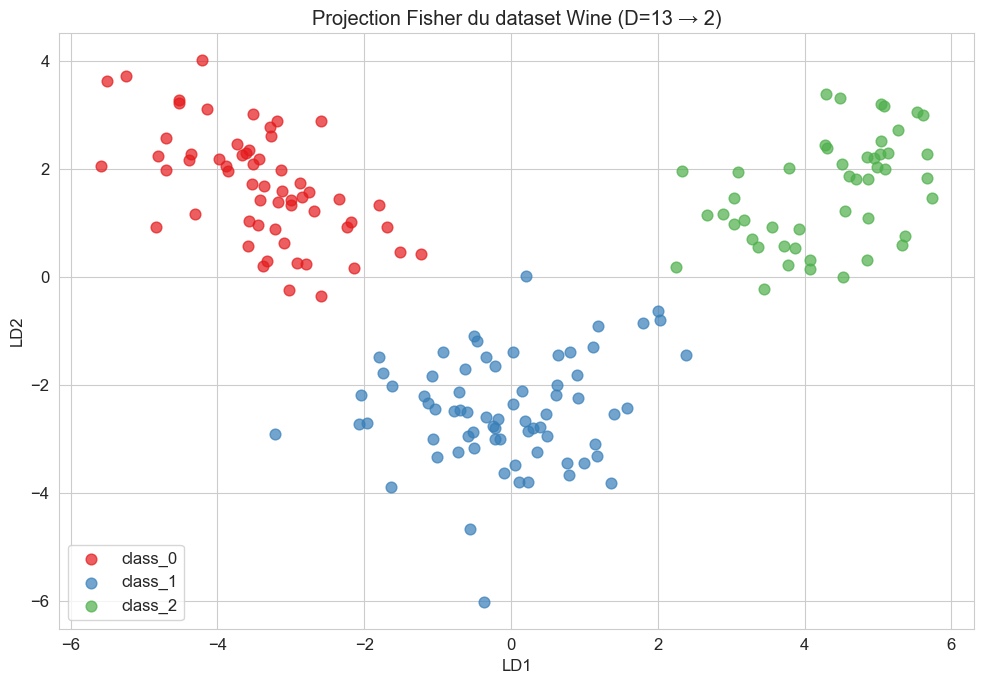


Variance expliquée : [0.68747889 0.31252111]
Total : 100.0%


In [34]:
# Dataset Wine (D=13, K=3)
wine = load_wine()
X_wine = wine.data
t_wine = wine.target

print(f"Dataset Wine : N={X_wine.shape[0]}, D={X_wine.shape[1]}, K=3")
print(f"Classes : {wine.target_names}")

# Fisher projette vers K-1 = 2 dimensions maximum
lda_wine = LinearDiscriminantAnalysis(n_components=2)
X_wine_lda = lda_wine.fit_transform(X_wine, t_wine)

# Visualisation
fig, ax = plt.subplots(figsize=(10, 7))
for k in range(3):
    mask = t_wine == k
    ax.scatter(X_wine_lda[mask, 0], X_wine_lda[mask, 1], 
               c=colors[k], label=wine.target_names[k], alpha=0.7, s=60)

ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_title(f'Projection Fisher du dataset Wine (D=13 → 2)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nVariance expliquée : {lda_wine.explained_variance_ratio_}")
print(f"Total : {lda_wine.explained_variance_ratio_.sum():.1%}")

---
# Partie 2 : Machines à Vecteurs de Support (SVM)
---

## 2.1 Concept de marge maximale

Les SVM cherchent l'hyperplan qui **maximise la marge** entre les classes.

$$\text{Marge} = \frac{2}{\|\mathbf{w}\|}$$

**Problème d'optimisation :**
$$\min_{\mathbf{w}, w_0} \frac{1}{2} \|\mathbf{w}\|^2 \quad \text{sous} \quad t_n(\mathbf{w}^\top \mathbf{x}_n + w_0) \geq 1 \;\; \forall n$$

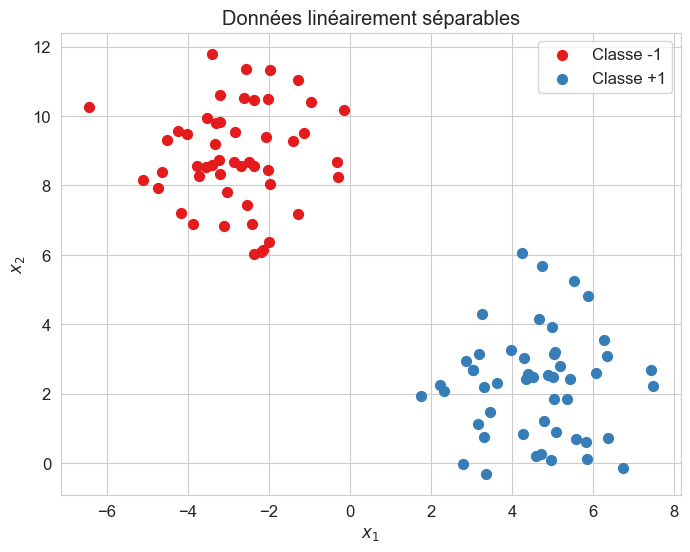

In [35]:
# Génération de données linéairement séparables
np.random.seed(42)
X_svm, t_svm = make_blobs(n_samples=100, centers=2, cluster_std=1.5, random_state=42)
t_svm = 2 * t_svm - 1  # Convertir en {-1, +1}

# Visualisation
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_svm[t_svm==-1, 0], X_svm[t_svm==-1, 1], c='#e41a1c', label='Classe -1', s=50)
ax.scatter(X_svm[t_svm==1, 0], X_svm[t_svm==1, 1], c='#377eb8', label='Classe +1', s=50)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Données linéairement séparables')
ax.legend()
plt.show()

In [36]:
def plot_svm_decision_boundary(clf, X, t, ax, title):
    """
    Trace la frontière de décision d'un SVM avec la marge et les vecteurs de support.
    """
    # Grille
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Fonction de décision
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Régions
    ax.contourf(xx, yy, Z, levels=[-100, 0, 100], alpha=0.3, 
                colors=['#ffcccc', '#ccccff'])
    
    # Frontière (y=0) et marges (y=-1, y=+1)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors=['#e41a1c', 'black', '#377eb8'],
               linestyles=['--', '-', '--'], linewidths=[1.5, 2, 1.5])
    
    # Points
    ax.scatter(X[t==-1, 0], X[t==-1, 1], c='#e41a1c', label='Classe -1', s=50, edgecolors='k')
    ax.scatter(X[t==1, 0], X[t==1, 1], c='#377eb8', label='Classe +1', s=50, edgecolors='k')
    
    # Vecteurs de support
    sv = clf.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=200, facecolors='none', 
               edgecolors='lime', linewidths=2, label='Vecteurs de support')
    
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(title)
    ax.legend(loc='best')
    
    return ax

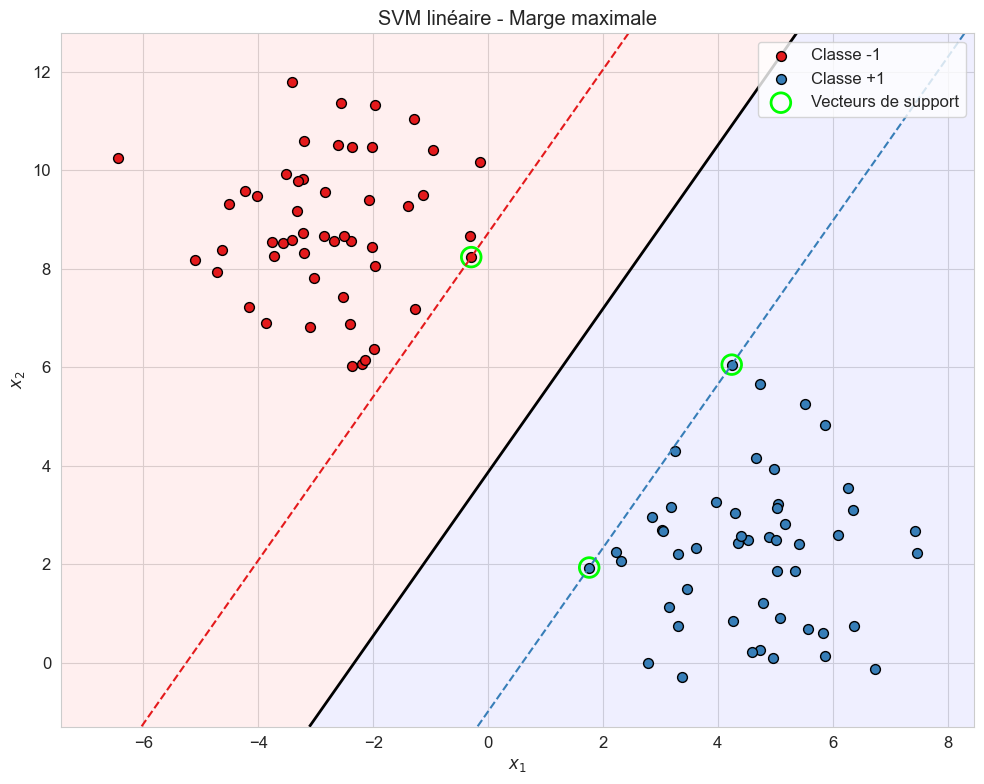

Nombre de vecteurs de support : 3
Vecteur w : [ 0.34185493 -0.20591293]
Biais w_0 : 0.7960
Marge = 2/||w|| = 5.0115


In [37]:
# Entraînement du SVM linéaire (marge dure)
svm_hard = SVC(kernel='linear', C=1e6)  # C très grand = marge dure
svm_hard.fit(X_svm, t_svm)

# Visualisation
fig, ax = plt.subplots(figsize=(10, 8))
plot_svm_decision_boundary(svm_hard, X_svm, t_svm, ax, 
                           'SVM linéaire - Marge maximale')
plt.tight_layout()
plt.show()

# Informations sur le modèle
print(f"Nombre de vecteurs de support : {len(svm_hard.support_)}")
print(f"Vecteur w : {svm_hard.coef_[0]}")
print(f"Biais w_0 : {svm_hard.intercept_[0]:.4f}")
print(f"Marge = 2/||w|| = {2/np.linalg.norm(svm_hard.coef_):.4f}")

### Question 3
Observez les vecteurs de support (cercles verts). Pourquoi sont-ils situés exactement sur la marge ?

## 2.2 Marge souple (Soft Margin)

Quand les données ne sont pas parfaitement séparables, on introduit des **variables de relaxation** $\xi_n$ :

$$\min_{\mathbf{w}, w_0, \boldsymbol{\xi}} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_n \xi_n$$

Le paramètre **C** contrôle le compromis :
- **C grand** : peu de violations, marge étroite
- **C petit** : plus de violations, marge large

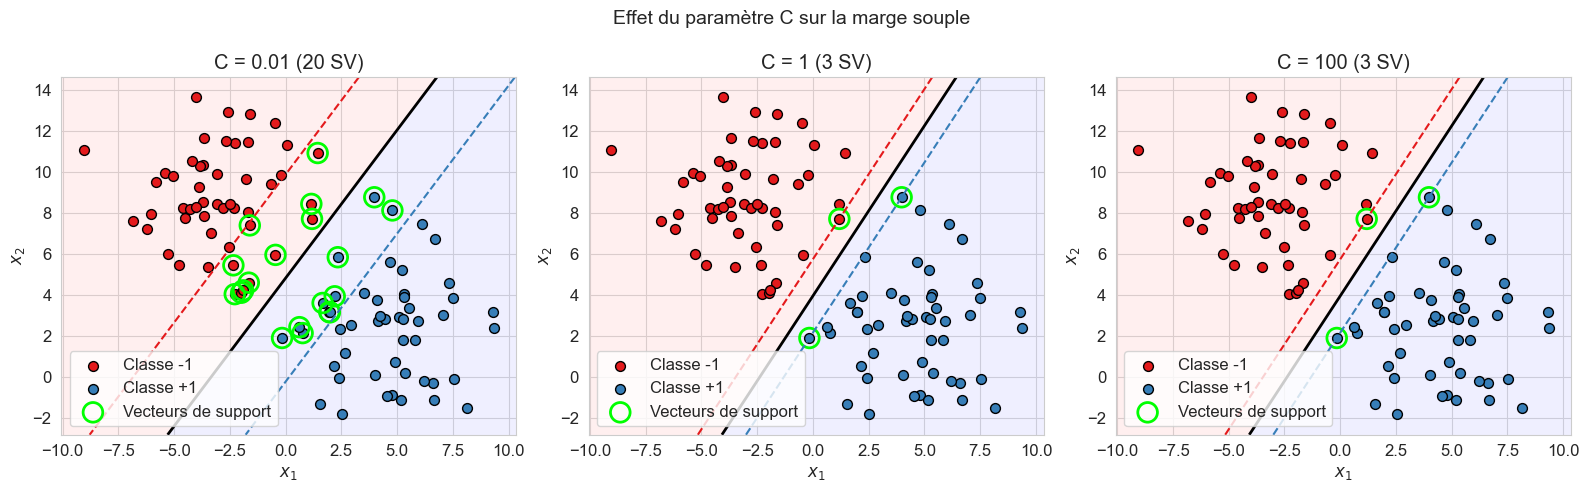

In [38]:
# Données avec chevauchement
np.random.seed(42)
X_overlap, t_overlap = make_blobs(n_samples=100, centers=2, cluster_std=2.5, random_state=42)
t_overlap = 2 * t_overlap - 1

# Effet du paramètre C
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

C_values = [0.01, 1, 100]

for ax, C in zip(axes, C_values):
    svm = SVC(kernel='linear', C=C)
    svm.fit(X_overlap, t_overlap)
    
    plot_svm_decision_boundary(svm, X_overlap, t_overlap, ax, 
                               f'C = {C} ({len(svm.support_)} SV)')

plt.suptitle('Effet du paramètre C sur la marge souple', fontsize=14)
plt.tight_layout()
plt.show()

### Question 4
Comment évolue le nombre de vecteurs de support avec C ? Quel C choisiriez-vous ?

## 2.3 Les multiplicateurs de Lagrange $\alpha_n$

La solution du dual donne les coefficients $\alpha_n$. La fonction de décision est :

$$y(\mathbf{x}) = \sum_{n=1}^{N} \alpha_n t_n \mathbf{x}_n^\top \mathbf{x} + w_0$$

Seuls les points avec $\alpha_n > 0$ (vecteurs de support) contribuent.

In [39]:
# Analyse des coefficients
svm = SVC(kernel='linear', C=1)
svm.fit(X_overlap, t_overlap)

# dual_coef_ = alpha_n * t_n pour les vecteurs de support
print(f"Nombre total de points : {len(X_overlap)}")
print(f"Nombre de vecteurs de support : {len(svm.support_)}")
print(f"\nIndices des vecteurs de support : {svm.support_[:10]}...")
print(f"\nCoefficients α_n * t_n (premiers 10) : {svm.dual_coef_[0][:10]}")

# Vérification : w = sum(alpha_n * t_n * x_n)
w_from_dual = (svm.dual_coef_ @ svm.support_vectors_).flatten()
w_direct = svm.coef_.flatten()

print(f"\nVérification w :")
print(f"  Depuis dual : {w_from_dual}")
print(f"  Depuis coef_ : {w_direct}")

Nombre total de points : 100
Nombre de vecteurs de support : 3

Indices des vecteurs de support : [45 29 63]...

Coefficients α_n * t_n (premiers 10) : [-0.58541051  0.41417486  0.17123565]

Vérification w :
  Depuis dual : [ 0.92676711 -0.5582276 ]
  Depuis coef_ : [ 0.92676711 -0.5582276 ]


## 2.4 SVM avec noyaux (Kernel Trick)

Le dual ne dépend que des produits scalaires $\mathbf{x}_n^\top \mathbf{x}_m$.

On peut les remplacer par un **noyau** $k(\mathbf{x}_n, \mathbf{x}_m)$ pour des frontières non-linéaires :

- **RBF** : $k(\mathbf{x}, \mathbf{x}') = \exp(-\gamma \|\mathbf{x} - \mathbf{x}'\|^2)$
- **Polynomial** : $k(\mathbf{x}, \mathbf{x}') = (\mathbf{x}^\top \mathbf{x}' + c)^d$

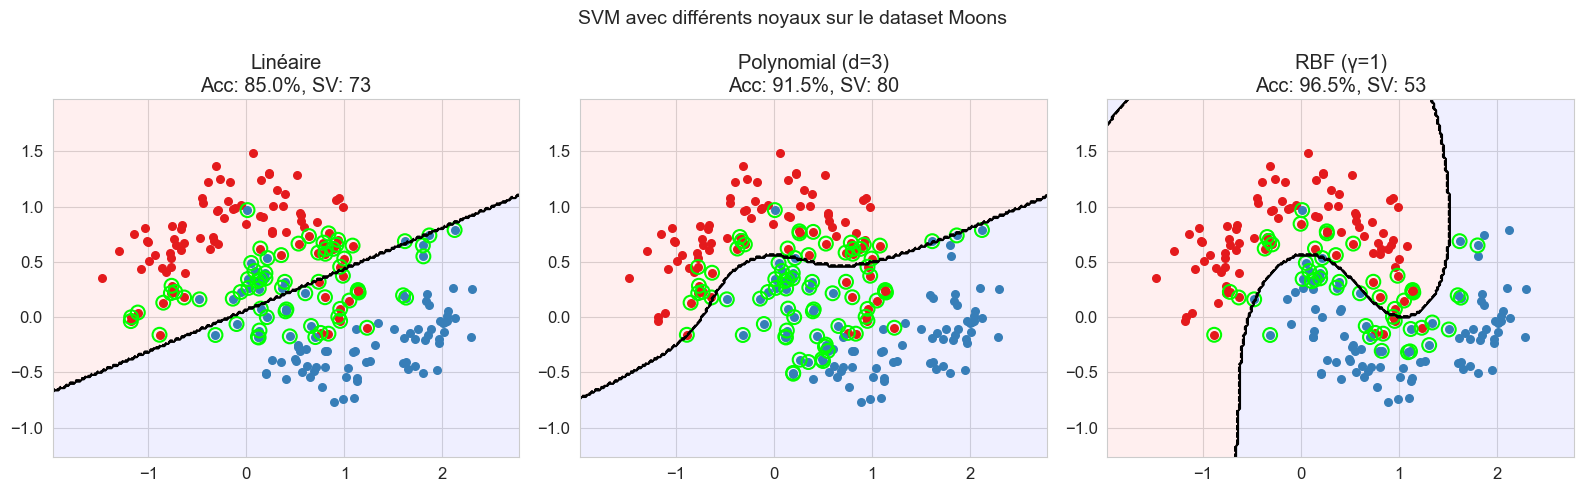

In [40]:
# Données non-linéairement séparables (moons)
X_moons, t_moons = make_moons(n_samples=200, noise=0.2, random_state=42)
t_moons = 2 * t_moons - 1

# Comparaison des noyaux
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

kernels = [
    ('linear', 'Linéaire'),
    ('poly', 'Polynomial (d=3)'),
    ('rbf', 'RBF (γ=1)')
]

for ax, (kernel, name) in zip(axes, kernels):
    if kernel == 'poly':
        svm = SVC(kernel=kernel, degree=3, C=1)
    elif kernel == 'rbf':
        svm = SVC(kernel=kernel, gamma=1, C=1)
    else:
        svm = SVC(kernel=kernel, C=1)
    
    svm.fit(X_moons, t_moons)
    acc = svm.score(X_moons, t_moons)
    
    # Grille pour contour
    h = 0.02
    x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
    y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#ffcccc', '#ccccff']))
    ax.contour(xx, yy, Z, colors='k', linewidths=1)
    ax.scatter(X_moons[t_moons==-1, 0], X_moons[t_moons==-1, 1], c='#e41a1c', s=30)
    ax.scatter(X_moons[t_moons==1, 0], X_moons[t_moons==1, 1], c='#377eb8', s=30)
    ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1], 
               s=100, facecolors='none', edgecolors='lime', linewidths=1.5)
    ax.set_title(f'{name}\nAcc: {acc:.1%}, SV: {len(svm.support_)}')

plt.suptitle('SVM avec différents noyaux sur le dataset Moons', fontsize=14)
plt.tight_layout()
plt.show()

## 2.5 Effet de gamma (RBF)

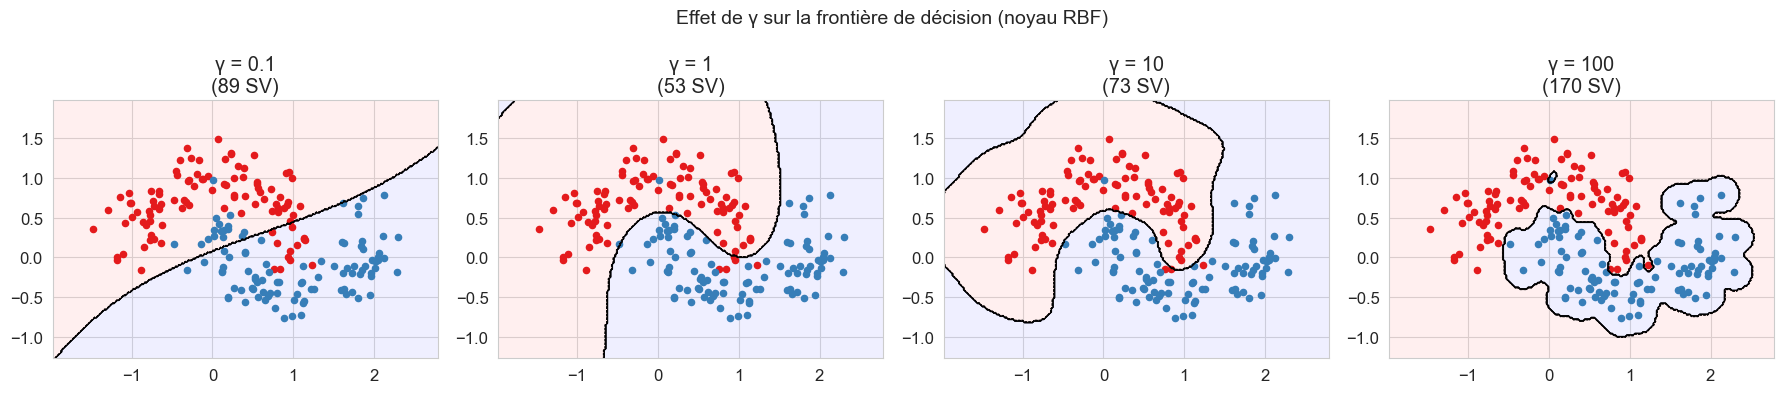

In [41]:
# Effet de gamma sur la complexité de la frontière
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

gamma_values = [0.1, 1, 10, 100]

for ax, gamma in zip(axes, gamma_values):
    svm = SVC(kernel='rbf', gamma=gamma, C=1)
    svm.fit(X_moons, t_moons)
    
    # Grille
    h = 0.02
    x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
    y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#ffcccc', '#ccccff']))
    ax.contour(xx, yy, Z, colors='k', linewidths=0.5)
    ax.scatter(X_moons[t_moons==-1, 0], X_moons[t_moons==-1, 1], c='#e41a1c', s=20)
    ax.scatter(X_moons[t_moons==1, 0], X_moons[t_moons==1, 1], c='#377eb8', s=20)
    ax.set_title(f'γ = {gamma}\n({len(svm.support_)} SV)')

plt.suptitle('Effet de γ sur la frontière de décision (noyau RBF)', fontsize=14)
plt.tight_layout()
plt.show()

### Question 5
Quel est l'effet de γ sur la frontière ? Lequel correspond au surapprentissage ?

## 2.6 Sélection des hyperparamètres par validation croisée

Meilleurs paramètres : {'C': 0.1, 'gamma': 10}
Meilleur score CV : 0.9750


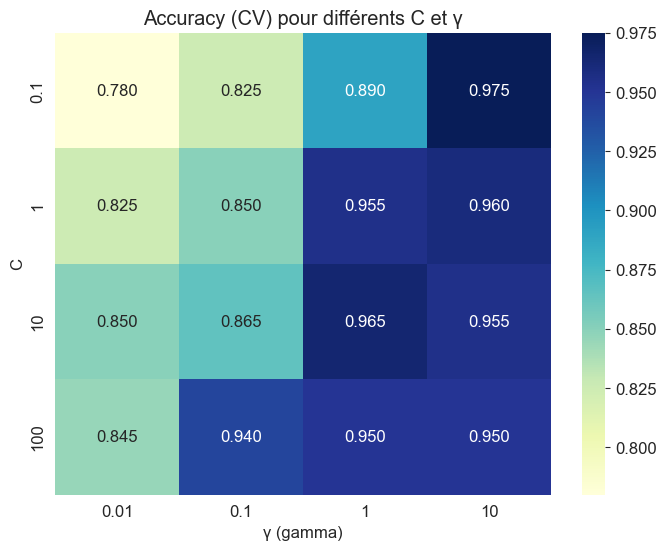

In [42]:
# Grid Search pour C et gamma
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 10]
}

grid_search = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_moons, t_moons)

print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score CV : {grid_search.best_score_:.4f}")

# Heatmap des scores
scores = grid_search.cv_results_['mean_test_score'].reshape(4, 4)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(scores, annot=True, fmt='.3f', 
            xticklabels=param_grid['gamma'],
            yticklabels=param_grid['C'],
            cmap='YlGnBu', ax=ax)
ax.set_xlabel('γ (gamma)')
ax.set_ylabel('C')
ax.set_title('Accuracy (CV) pour différents C et γ')
plt.show()

## 2.7 Comparaison sur Iris

In [43]:
# Comparaison Fisher + classifieur vs SVM sur Iris
X_train, X_test, t_train, t_test = train_test_split(
    X_iris, t_iris, test_size=0.3, random_state=42, stratify=t_iris
)

# Méthodes à comparer
methods = {
    'LDA (Fisher)': LinearDiscriminantAnalysis(),
    'SVM linéaire': SVC(kernel='linear', C=1),
    'SVM RBF': SVC(kernel='rbf', C=1, gamma='scale'),
    'SVM poly (d=3)': SVC(kernel='poly', degree=3, C=1)
}

print("Performance sur Iris (test set) :")
print("=" * 50)

results = {}
for name, clf in methods.items():
    clf.fit(X_train, t_train)
    acc = clf.score(X_test, t_test)
    results[name] = acc
    
    # Nombre de vecteurs de support pour SVM
    if hasattr(clf, 'support_'):
        n_sv = len(clf.support_)
        print(f"{name:<20} : {acc:.4f}  (SV: {n_sv})")
    else:
        print(f"{name:<20} : {acc:.4f}")

Performance sur Iris (test set) :
LDA (Fisher)         : 0.9778
SVM linéaire         : 1.0000  (SV: 20)
SVM RBF              : 0.9556  (SV: 45)
SVM poly (d=3)       : 0.9556  (SV: 15)


---
# Exercices
---

## Exercice 1 : Implémentation du critère de Fisher

Complétez la fonction pour calculer le critère de Fisher $J(\mathbf{w})$ pour une direction donnée.

In [44]:
def fisher_criterion(X, t, w):
    """
    Calcule le critère de Fisher J(w) = w^T S_B w / w^T S_W w
    
    Paramètres:
    -----------
    X : array (N, D)
    t : array (N,) avec valeurs {0, 1}
    w : array (D,) - direction de projection
    
    Retourne:
    ---------
    J : float - valeur du critère
    """
    # TODO: Compléter
    
    # 1. Calculer les moyennes projetées m_1 et m_2
    m1 = X[t == 0] @ w
    m2 = X[t == 1] @ w
    m1_mean = m1.mean()
    m2_mean = m2.mean()
    
    # 2. Calculer les variances projetées s_1^2 et s_2^2
    s1_sq = m1.var() * len(m1)
    s2_sq = m2.var() * len(m2)
    
    # 3. Calculer J = (m1 - m2)^2 / (s1^2 + s2^2)
    J = (m1_mean - m2_mean)**2 / (s1_sq + s2_sq + 1e-10)
    
    return J

# Test
w_test = np.array([1, 0])  # Direction x1
J_test = fisher_criterion(X_demo, t_demo, w_test)
print(f"J(w=[1,0]) = {J_test:.4f}")

J_optimal = fisher_criterion(X_demo, t_demo, W_manual.flatten())
print(f"J(w_Fisher) = {J_optimal:.4f}")

J(w=[1,0]) = 0.0126
J(w_Fisher) = 0.0196


## Exercice 2 : Calcul manuel de la marge SVM

Vérifiez que les vecteurs de support sont bien sur la marge.

In [46]:
# Entraîner un SVM linéaire
svm_test = SVC(kernel='linear', C=1e6)
svm_test.fit(X_svm, t_svm)

w = svm_test.coef_[0]
w0 = svm_test.intercept_[0]

# Calcul de la marge
margin = 2 / np.linalg.norm(w)
print(f"Marge γ = 2/||w|| = {margin:.4f}")

# Vérification : distance des vecteurs de support à l'hyperplan
print("\nDistances des vecteurs de support à l'hyperplan :")
for i, sv in enumerate(svm_test.support_vectors_):
    y_sv = w @ sv + w0
    dist = np.abs(y_sv) / np.linalg.norm(w)
    print(f"  SV {i+1}: y(x) = {y_sv:.4f}, distance = {dist:.4f}")

print(f"\nMarge/2 attendue : {margin/2:.4f}")

Marge γ = 2/||w|| = 5.0115

Distances des vecteurs de support à l'hyperplan :
  SV 1: y(x) = -1.0001, distance = 2.5059
  SV 2: y(x) = 0.9999, distance = 2.5056
  SV 3: y(x) = 1.0001, distance = 2.5060

Marge/2 attendue : 2.5058


## Exercice 3 : Comparaison complète sur Wine

Validation croisée (5-fold) sur Wine :
LDA (Fisher)         : 0.9717 (+/- 0.0504)
SVM linéaire         : 0.9551 (+/- 0.0274)
SVM RBF              : 0.9889 (+/- 0.0272)
SVM poly             : 0.9437 (+/- 0.0629)


C:\Users\cleme\AppData\Local\Temp\ipykernel_14384\970685777.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(wine_results.values(), labels=wine_results.keys())


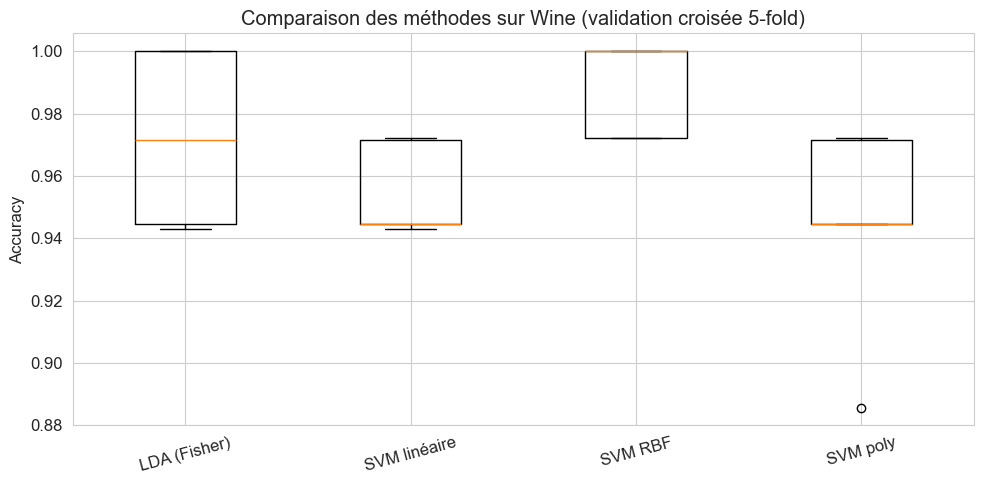

In [47]:
# Standardisation
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

# Toutes les méthodes
all_methods = {
    'LDA (Fisher)': LinearDiscriminantAnalysis(),
    'SVM linéaire': SVC(kernel='linear', C=1),
    'SVM RBF': SVC(kernel='rbf', C=10, gamma='scale'),
    'SVM poly': SVC(kernel='poly', degree=3, C=1),
}

print("Validation croisée (5-fold) sur Wine :")
print("=" * 55)

wine_results = {}
for name, clf in all_methods.items():
    if 'SVM' in name:
        scores = cross_val_score(clf, X_wine_scaled, t_wine, cv=5)
    else:
        scores = cross_val_score(clf, X_wine, t_wine, cv=5)
    wine_results[name] = scores
    print(f"{name:<20} : {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(wine_results.values(), labels=wine_results.keys())
ax.set_ylabel('Accuracy')
ax.set_title('Comparaison des méthodes sur Wine (validation croisée 5-fold)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

---
## Conclusion

### Analyse Discriminante de Fisher
1. Le critère de Fisher maximise $J(\mathbf{w}) = \frac{\mathbf{w}^\top \mathbf{S}_B \mathbf{w}}{\mathbf{w}^\top \mathbf{S}_W \mathbf{w}}$
2. La solution optimale est $\mathbf{w}^* \propto \mathbf{S}_W^{-1}(\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)$
3. Fisher donne la même direction que LDA sous hypothèses gaussiennes
4. Fisher est supérieur à PCA pour la classification (supervisé vs non-supervisé)

### SVM
1. Les SVM maximisent la **marge** entre les classes
2. Seuls les **vecteurs de support** (points sur la marge) définissent la solution
3. Le paramètre **C** contrôle le compromis marge/erreurs
4. Le **kernel trick** permet des frontières non-linéaires
5. Le paramètre **γ** (RBF) contrôle la complexité de la frontière